|<img style="float:left;" src="images/usherb_transp.gif" > |Pierre Proulx, ing, professeur|
|:---|:---|
|Département de génie chimique et de génie biotechnologique |** GCH200-Phénomènes d'échanges I **|



### Section 18-2, diffusion binaire dans un milieu stagnant

<img src='images/Chap-18-Section-18-2.png'>

Voir les hypothèses dans le livre de Transport Phenomena.


In [1]:
#
# Pierre Proulx
#
#
# Préparation de l'affichage et des outils de calcul symbolique
#
import sympy as sp
from IPython.display import *
sp.init_printing(use_latex=True)
%matplotlib inline

In [2]:
# Paramètres, variables et fonctions

z_1,z_2,z,D_AB,X_A1,X_A2,S,delta_z,C1,C2,L=sp.symbols('z_1,z_2,z,D_AB,X_A1,X_A2,S,delta_z,C1,C2,L')                                                            
N_A=sp.Function('N_A')
X_A=sp.Function('X_A')(z)     

In [3]:
#
# Bilan sur la colonne de diffusion
#
eq=(S*N_A(z)-S*N_A(z+delta_z))/(S*delta_z)
display(eq)

In [4]:
eq=sp.limit(eq,delta_z,0).doit()
display(eq)

In [5]:
N_A=sp.dsolve(eq)
display(N_A)

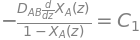

In [6]:
fick=-D_AB/(1-X_A)*sp.diff(X_A,z)
eq=sp.Eq(N_A.subs(N_A,fick),N_A.rhs)
display(eq)

In [7]:
X_A=sp.dsolve(eq,X_A)
display(X_A)

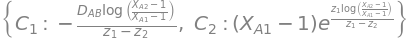

In [8]:
X_A=X_A.rhs
# Pose et solution des 2 équations de conditions aux limites pour C1 et C2
condition_1=sp.Eq(X_A.subs(z,z_1)-X_A1,0)
condition_2=sp.Eq(X_A.subs(z,z_2)-X_A2,0)
constantes=sp.solve([condition_1,condition_2],sp.symbols('C1,C2'),dict=True) # C1 et C2
constantes=constantes[0]         # ramener la liste contenant le dictionnaire des constantes

display(constantes)              # sous forme de dictionnaire

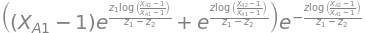

In [9]:
X_A=X_A.subs(constantes)             #
X_A=X_A.simplify()
#
# La forme de l'équation est lourde, voir plus bas pour formuler de façon plus simple.
#
display(X_A)

In [10]:
#
# Tracons avec des valeurs réalistes, en mode interactif 
#
from ipywidgets import *
dico={'z_1':0,'z_2':0.2,'X_A1':0.5,'X_A2':0.1}
def graphe(x1,x2,z2):
    X_Aplot=X_A.subs(dico)
    display(X_Aplot)
    import matplotlib.pyplot as plt
    plt.rcParams['figure.figsize']=10,8
    sp.plot(X_Aplot,(z,z_1.subs(dico),z_2.subs(dico)),ylabel='X_A',ylim=[0,1],adaptive=True);

In [11]:
interact(graphe,x1=(0.1,0.9,0.01),x2=(0.01,0.09,0.01),z2=(0.01,0.5,0.01),continuous_update=False)

interactive(children=(FloatSlider(value=0.5, description='x1', max=0.9, min=0.1, step=0.01), FloatSlider(value…

<function __main__.graphe(x1, x2, z2)>